# **Build Self Attention from Scratch**

# Self-Attention vs Attention

## Self-Attention (Description)

Self-attention is a mechanism that allows a model to relate different positions within the same input sequence to understand contextual relationships. Instead of processing each token independently, self-attention lets every token “look at” all other tokens in the sequence and decide which ones are most relevant to it.

For each token, the model creates three vectors: **Query (Q)**, **Key (K)**, and **Value (V)**. It then compares the query of one token with the keys of all tokens to compute similarity scores. These scores determine how much attention each token should give to every other token. The final output is a weighted combination of the value vectors, where weights come from these attention scores.

---

## Attention vs Self-Attention (Learnable Parameters Comparison)

### 1. Attention (General / Encoder-Decoder Attention)

- Used when **Query comes from one sequence** and **Keys/Values come from another sequence**
- Example: Machine translation (decoder attends to encoder outputs)

**Learnable Parameters:**
- \( W_Q, W_K, W_V \)

**Key Idea:**
- Interaction between two different sequences

---

### 2. Self-Attention

- Query, Key, and Value all come from the **same sequence**
- Each token attends to every other token in the same input

**Learnable Parameters:**
- \( W_Q, W_K, W_V \)

**Key Idea:**
- Captures relationships within a single sequence

---

## Key Difference Summary

| Aspect | Attention | Self-Attention |
|--------|----------|----------------|
| Input Source | Two different sequences | Same sequence |
| Q, K, V Origin | Encoder → Decoder | Same input embedding |
| Learnable Parameters | \(W_Q, W_K, W_V\) | \(W_Q, W_K, W_V\) |
| Purpose | Cross-sequence alignment | Intra-sequence relationship modeling |

---

## Summary

Both attention and self-attention use the same learnable parameter matrices, but they differ in how inputs are used. Self-attention focuses on relationships within a single sequence, enabling models to capture context more effectively.

In [200]:
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

### Initializing the Head

In [201]:
import torch
import torch.nn as nn

In [202]:
class Head(nn.Module):
    
    def __init__(self, vocab_size, embed_dim, ):
        super(Head, self).__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        
        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        self.query = nn.Linear(embed_dim, embed_dim, bias=False)
        self.key = nn.Linear(embed_dim, embed_dim, bias=False)
        self.value = nn.Linear(embed_dim,embed_dim, bias=False)
    
    def attention(self, x):
        embed_out = self.embeddings(x)
        
        q = self.query(embed_out)
        k = self.key(embed_out)
        v = self.value(embed_out)
        
        w = q @ k.transpose(-2,-1) * k.shape[-1] ** -0.5
        w = torch.nn.functional.softmax(w,dim =-1)
        
        return embed_out,w,q,k,v
    
    def forward(self, x):
        embed_out = self.embeddings(x)
        
        q = self.query(embed_out)
        k = self.key(embed_out)
        v = self.value(embed_out)
        
        #attention score
        w = q @ k.transpose(-2,-1) * k.shape[-1] ** -0.5
        w = torch.nn.functional.softmax(w, dim = -1)
        # Add weighted values
        out = w @ v
        
        return out    

### Dataset Defining

In [203]:
dataset = [
    (2, "PyTorch is widely used for deep learning models"),
    (1, "text classification using NLP techniques"),
    (3, "the red car was driven by him"),
    (1, "Introduction to NLP and its real world applications"),
    (3, "YOLO detects objects in real time video streams"),
    (2, "sequence models like RNNs handle time dependent data"),
    (1, "Named Entity Recognition extracts entities from text"),
    (3, "the blue car moved quickly across the road"),
    (2, "Transformers rely on attention mechanisms"),
    (1, "tokenization and embeddings are key NLP steps"),
    (3, "U-Net is used for medical image segmentation"),
    (2, "Large Language Models understand context better than RNNs"),
    (1, "sentiment analysis determines emotional tone of text"),
    (3, "a car painted red was seen on the street"),
    (2, "self attention helps models focus on relevant words in a sentence"),
]

### Tokenization

In [204]:


tokenizor = get_tokenizer("basic_english")

#### Data Iterator

In [205]:
def yield_tokens(data):
    for _,text in data:
        yield  tokenizor(text)

#### Vocabulary

In [206]:
vocab = build_vocab_from_iterator(yield_tokens(dataset), specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])

#### Text Pipeline

In [207]:
def text_pipeline(x):
    return vocab(tokenizor(x)) # convert text into list of token indices

#### Hyper Parameters Defining

In [208]:
vocab_size = len(vocab)
embed_dim = 3

In [209]:
attention_head = Head(vocab_size,embed_dim)

### Testing Layers (for sample data)

In [210]:
sample_text = 'he painted the car red'
my_tokens = text_pipeline(sample_text)

input_data = torch.tensor(my_tokens,dtype=torch.long)

In [211]:
print(f"input data: {input_data}")
print(f"inpt shape: {input_data.shape}")

input data: tensor([ 0, 58,  2,  3, 14])
inpt shape: torch.Size([5])


In [212]:
embed_out, w, q, k, v = attention_head.attention(input_data)
print(f"embed out: {embed_out}")
print("\n")
print(f"weights: {w}")
print("\n")
print(f"query: {q}")
print("\n")
print(f"key: {k}")
print("\n")
print(f"value: {v}")

embed out: tensor([[ 0.2579, -0.7267, -1.4783],
        [-1.7196, -1.3862, -0.5303],
        [ 0.0294,  0.7859,  0.3328],
        [ 0.4631, -1.0362,  0.7234],
        [-0.1917, -2.1724,  0.1593]], grad_fn=<EmbeddingBackward0>)


weights: tensor([[0.3214, 0.1343, 0.2003, 0.1808, 0.1631],
        [0.1753, 0.2301, 0.1906, 0.1954, 0.2086],
        [0.1511, 0.2122, 0.2176, 0.2155, 0.2035],
        [0.2819, 0.2102, 0.1418, 0.1602, 0.2059],
        [0.3297, 0.1997, 0.1277, 0.1453, 0.1975]], grad_fn=<SoftmaxBackward0>)


query: tensor([[-0.9944,  0.0584,  0.0878],
        [ 0.1153,  0.2227,  0.0351],
        [ 0.4598, -0.1383, -0.3439],
        [-0.4678,  0.2629,  0.9584],
        [-0.8292,  0.4485,  1.2165]], grad_fn=<MmBackward0>)


key: tensor([[-0.7299, -0.4183,  0.6747],
        [ 0.8569,  0.8941,  0.5587],
        [ 0.0310, -0.0088, -0.3084],
        [ 0.2388,  0.0277,  0.0040],
        [ 0.4799,  0.3382,  0.4904]], grad_fn=<MmBackward0>)


value: tensor([[ 0.6504,  0.4851, -0.3716],
   

## **Positional Encoding**

# Positional Encoding

In sequence processing tasks, understanding the order of elements is essential because changing the position of words can completely change the meaning of a sentence. For example, consider the sentences: *“The dog chased the cat”* and *“The cat chased the dog.”* Although both sentences contain the same words, their meanings are different due to the change in word positions. To help a model capture this order information, positional encoding is used.

This is achieved by assigning each token in a sequence a unique position index, where the first element is assigned index 0, the second index 1, and so on, represented as \( p_n = n \), where \( n \) denotes the position in the sequence. By adding this positional information to the word embeddings, the model can distinguish between words based not only on their meaning but also on their order in the sentence.

For instance, in the sentence *“The cat chased the dog”*, the word *“cat”* appears at position 1, while in another sentence it may appear at a different position, and this difference is captured through positional encoding. This simple yet powerful technique enables models to understand structure and sequence effectively, improving performance in language-related tasks, especially when dealing with long sentences.

In [213]:
positions = torch.arange(0, vocab_size,dtype=torch.float)
positions, positions.shape

(tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
         14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27.,
         28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41.,
         42., 43., 44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54., 55.,
         56., 57., 58., 59., 60., 61., 62., 63., 64., 65., 66., 67., 68., 69.,
         70., 71., 72., 73., 74., 75., 76., 77., 78., 79., 80., 81., 82., 83.,
         84., 85., 86., 87.]),
 torch.Size([88]))

In [214]:
# we convert it to 2D tensor
positions = positions.unsqueeze(1)
positions, positions.shape

(tensor([[ 0.],
         [ 1.],
         [ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.],
         [11.],
         [12.],
         [13.],
         [14.],
         [15.],
         [16.],
         [17.],
         [18.],
         [19.],
         [20.],
         [21.],
         [22.],
         [23.],
         [24.],
         [25.],
         [26.],
         [27.],
         [28.],
         [29.],
         [30.],
         [31.],
         [32.],
         [33.],
         [34.],
         [35.],
         [36.],
         [37.],
         [38.],
         [39.],
         [40.],
         [41.],
         [42.],
         [43.],
         [44.],
         [45.],
         [46.],
         [47.],
         [48.],
         [49.],
         [50.],
         [51.],
         [52.],
         [53.],
         [54.],
         [55.],
         [56.],
         [57.],
         [58.],
         [59.],
         [60.],
         [61.],
        

In [215]:
# make a list that mapping token indices to tokens
vocab_list = list(vocab.get_itos())

# iterrate through the vocab list
for id in range(vocab_size):
    word = vocab_list[id]
    word_pos =  positions[id][0].item()
    print(f"word: {word}, relevat position:{word_pos}")



word: <unk>, relevat position:0.0
word: models, relevat position:1.0
word: the, relevat position:2.0
word: car, relevat position:3.0
word: nlp, relevat position:4.0
word: on, relevat position:5.0
word: text, relevat position:6.0
word: a, relevat position:7.0
word: and, relevat position:8.0
word: attention, relevat position:9.0
word: for, relevat position:10.0
word: in, relevat position:11.0
word: is, relevat position:12.0
word: real, relevat position:13.0
word: red, relevat position:14.0
word: rnns, relevat position:15.0
word: time, relevat position:16.0
word: used, relevat position:17.0
word: was, relevat position:18.0
word: across, relevat position:19.0
word: analysis, relevat position:20.0
word: applications, relevat position:21.0
word: are, relevat position:22.0
word: better, relevat position:23.0
word: blue, relevat position:24.0
word: by, relevat position:25.0
word: classification, relevat position:26.0
word: context, relevat position:27.0
word: data, relevat position:28.0
word: 

In positional encodings, each dimension \(d\) within the embedding holds specific importance, denoted as $\textbf{p}_{n,d}$. For example, if you have an embedding dimension of three, the positional encodings $\textbf{p}_{n,d}$ ​are represented as $[\text{ }p_{n,1},\text{ }p_{n,2},\text{ }p_{n,3}]$. These values correspond to a three-dimensional embedding for each token, capturing its position and unique characteristics within the sequence. By organizing positional information this way, the model gains a richer understanding of the relationship between tokens.


In [216]:
# initializing a matrix with dimension (vocab_size, embed_dim)
# This will be used to hold the positional encodings for each word in the vocabulary
positional_encoding = torch.zeros(vocab_size, embed_dim)

In [217]:
pe = torch.cat((positions,positions,positions),1)
pe

tensor([[ 0.,  0.,  0.],
        [ 1.,  1.,  1.],
        [ 2.,  2.,  2.],
        [ 3.,  3.,  3.],
        [ 4.,  4.,  4.],
        [ 5.,  5.,  5.],
        [ 6.,  6.,  6.],
        [ 7.,  7.,  7.],
        [ 8.,  8.,  8.],
        [ 9.,  9.,  9.],
        [10., 10., 10.],
        [11., 11., 11.],
        [12., 12., 12.],
        [13., 13., 13.],
        [14., 14., 14.],
        [15., 15., 15.],
        [16., 16., 16.],
        [17., 17., 17.],
        [18., 18., 18.],
        [19., 19., 19.],
        [20., 20., 20.],
        [21., 21., 21.],
        [22., 22., 22.],
        [23., 23., 23.],
        [24., 24., 24.],
        [25., 25., 25.],
        [26., 26., 26.],
        [27., 27., 27.],
        [28., 28., 28.],
        [29., 29., 29.],
        [30., 30., 30.],
        [31., 31., 31.],
        [32., 32., 32.],
        [33., 33., 33.],
        [34., 34., 34.],
        [35., 35., 35.],
        [36., 36., 36.],
        [37., 37., 37.],
        [38., 38., 38.],
        [39., 39., 39.],


In [218]:
embed_out

tensor([[ 0.2579, -0.7267, -1.4783],
        [-1.7196, -1.3862, -0.5303],
        [ 0.0294,  0.7859,  0.3328],
        [ 0.4631, -1.0362,  0.7234],
        [-0.1917, -2.1724,  0.1593]], grad_fn=<EmbeddingBackward0>)

In [219]:
# Print the tuple (samples, dim) to show the size of the batch and the embedding dimension
samples, dims = embed_out.shape
samples, dims

(5, 3)

In [220]:
# get the positional encoding for the range of samples and dims
pe_slice = pe[0:samples,0:dims]
pe_slice

tensor([[0., 0., 0.],
        [1., 1., 1.],
        [2., 2., 2.],
        [3., 3., 3.],
        [4., 4., 4.]])

### **`Positional Embedding = Positional Encoding + Embedding_vector(Embedding Layer)`**

In [221]:
positional_embedding = embed_out + pe_slice
# This step integrates the position information into the embeddings
positional_embedding

tensor([[ 0.2579, -0.7267, -1.4783],
        [-0.7196, -0.3862,  0.4697],
        [ 2.0294,  2.7859,  2.3328],
        [ 3.4631,  1.9638,  3.7234],
        [ 3.8083,  1.8276,  4.1593]], grad_fn=<AddBackward0>)

### **Plot Embeddings**

In [222]:
import matplotlib.pyplot as plt
import numpy as np 

In [223]:
def plot_embeddings (my_embeddings,name,vocab):
    fig = plt.figure()
    
    ax = fig.add_subplot(111, projection='3d')
    
    # plot datapoints
    ax.scatter(my_embeddings[:,0], my_embeddings[:,1], my_embeddings[:,2])
    
    for j, label in enumerate(name):
        #index = vocab.get_stoi()[label]
        ax.text(my_embeddings[j,0], my_embeddings[j,1], my_embeddings[j,2],label)
        
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    
    plt.show()
    

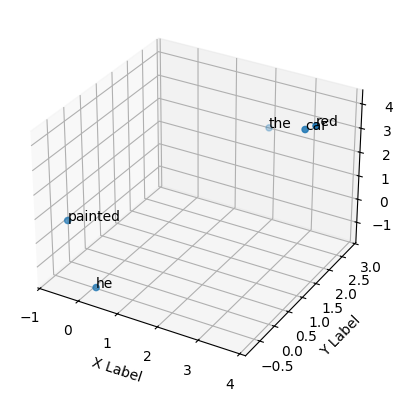

In [224]:
plot_embeddings(positional_embedding.detach().numpy(), tokenizor(sample_text),vocab)

In [225]:
positional_embedding[3]

tensor([3.4631, 1.9638, 3.7234], grad_fn=<SelectBackward0>)

In [226]:
positional_embedding[-1]

tensor([3.8083, 1.8276, 4.1593], grad_fn=<SelectBackward0>)

* So as we get combination of positional encoding to the text embedding it gives a more divergence to the positional embeding as the final outcome. So some embedding values can be smaller when some embedding values can be very larger 

Address this magnitude issue through various approaches. First, employ a function that doesn't exhibit such significant amplification. Additionally, have the option to introduce different functions. For instance, when considering our word positional encodings, the magnitude of the positional encodings $\textbf{p}_{n,d}$ can be represented as $[p_{n,1}, p_{n,2}, p_{n,3}]$, which, in this case, translates to $[0.1n, -0.1n, 0]$.

In this modified scheme, the magnitudes of the first two dimensions $[p_{n,1}, p_{n,2}]$ increase linearly with the position $n$ but at a slower rate (0.1 times the position). The third dimension $[p_{n,3}]$ remains constant at 0. Adjusting these coefficients, can control the rate at which the magnitudes change, ensuring that the embeddings do not escalate significantly and providing a more balanced representation of positions within the sequence.


In [227]:
pe = torch.cat((0.1*positions, -0.1* positions, 0 * positions),1)
pe

tensor([[ 0.0000, -0.0000,  0.0000],
        [ 0.1000, -0.1000,  0.0000],
        [ 0.2000, -0.2000,  0.0000],
        [ 0.3000, -0.3000,  0.0000],
        [ 0.4000, -0.4000,  0.0000],
        [ 0.5000, -0.5000,  0.0000],
        [ 0.6000, -0.6000,  0.0000],
        [ 0.7000, -0.7000,  0.0000],
        [ 0.8000, -0.8000,  0.0000],
        [ 0.9000, -0.9000,  0.0000],
        [ 1.0000, -1.0000,  0.0000],
        [ 1.1000, -1.1000,  0.0000],
        [ 1.2000, -1.2000,  0.0000],
        [ 1.3000, -1.3000,  0.0000],
        [ 1.4000, -1.4000,  0.0000],
        [ 1.5000, -1.5000,  0.0000],
        [ 1.6000, -1.6000,  0.0000],
        [ 1.7000, -1.7000,  0.0000],
        [ 1.8000, -1.8000,  0.0000],
        [ 1.9000, -1.9000,  0.0000],
        [ 2.0000, -2.0000,  0.0000],
        [ 2.1000, -2.1000,  0.0000],
        [ 2.2000, -2.2000,  0.0000],
        [ 2.3000, -2.3000,  0.0000],
        [ 2.4000, -2.4000,  0.0000],
        [ 2.5000, -2.5000,  0.0000],
        [ 2.6000, -2.6000,  0.0000],
 

plot positional encodings

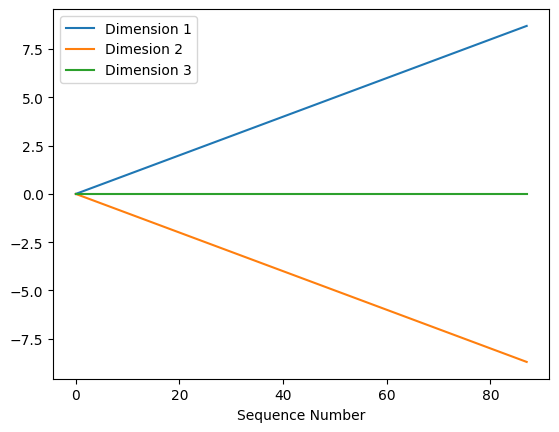

In [228]:
# plot 0 dimension positional encoding
plt.plot(pe[:,0].numpy(), label = "Dimension 1")
plt.plot(pe[:,1].numpy(), label = "Dimesion 2")
plt.plot(pe[:,2].numpy(), label = "Dimension 3")

plt.xlabel("Sequence Number")
plt.legend()
plt.show()

**After changing the Positional Encodings**


In [229]:
pe_slice_new = pe[0:samples, 0:dims]

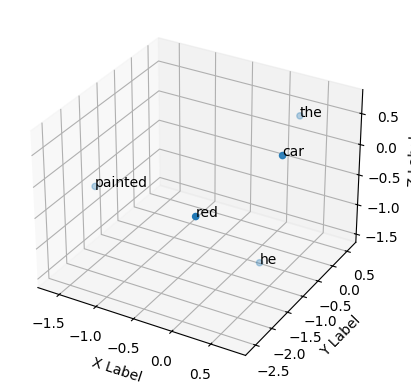

In [230]:
pos_embedding_changed = embed_out + pe_slice_new
plot_embeddings(pos_embedding_changed.detach().numpy(), tokenizor(sample_text), vocab)


When analyze positional encodings, it might appear that the words are closer together, indicating an improvement. However, it's crucial to recognize that the use of a linear function still comes with its own set of limitations. Despite the visual impression of words being in closer proximity, linear positional encodings have inherent issues. One significant problem is the potential for amplifying magnitudes as positions progress, which can adversely affect the model's ability to capture subtle positional nuances effectively.

To overcome these challenges, exploring alternative methods and functions for generating positional encodings is valuable. One promising approach involves leveraging periodic functions, such as sine and cosine functions. These functions possess a unique property called periodicity, meaning they repeat their values over regular intervals. This periodic nature prevents them from growing too rapidly as positions increase in the sequence.

By incorporating sine and cosine functions into positional encodings, introduces a more context-aware and adaptive mechanism. These functions allow us to capture the sequential information without the risk of magnitudes escalating uncontrollably. As a result, the model can better discern the relative positions of words within the sequence, leading to more accurate and meaningful representations.


In [231]:
pe = torch.cat((torch.sin(2*3.14*positions/6), 0* positions +1, 0 * positions +1),axis=1)
pe

tensor([[ 0.0000,  1.0000,  1.0000],
        [ 0.8658,  1.0000,  1.0000],
        [ 0.8666,  1.0000,  1.0000],
        [ 0.0016,  1.0000,  1.0000],
        [-0.8650,  1.0000,  1.0000],
        [-0.8673,  1.0000,  1.0000],
        [-0.0032,  1.0000,  1.0000],
        [ 0.8642,  1.0000,  1.0000],
        [ 0.8681,  1.0000,  1.0000],
        [ 0.0048,  1.0000,  1.0000],
        [-0.8634,  1.0000,  1.0000],
        [-0.8689,  1.0000,  1.0000],
        [-0.0064,  1.0000,  1.0000],
        [ 0.8626,  1.0000,  1.0000],
        [ 0.8697,  1.0000,  1.0000],
        [ 0.0080,  1.0000,  1.0000],
        [-0.8617,  1.0000,  1.0000],
        [-0.8705,  1.0000,  1.0000],
        [-0.0096,  1.0000,  1.0000],
        [ 0.8609,  1.0000,  1.0000],
        [ 0.8713,  1.0000,  1.0000],
        [ 0.0111,  1.0000,  1.0000],
        [-0.8601,  1.0000,  1.0000],
        [-0.8721,  1.0000,  1.0000],
        [-0.0127,  1.0000,  1.0000],
        [ 0.8593,  1.0000,  1.0000],
        [ 0.8728,  1.0000,  1.0000],
 

In [232]:
pe_slice_sin = pe[0:samples,0:dims]
pe_slice_sin

tensor([[ 0.0000,  1.0000,  1.0000],
        [ 0.8658,  1.0000,  1.0000],
        [ 0.8666,  1.0000,  1.0000],
        [ 0.0016,  1.0000,  1.0000],
        [-0.8650,  1.0000,  1.0000]])

In [233]:
positional_embedding_sin = embed_out + pe_slice_sin
positional_embedding_sin

tensor([[ 0.2579,  0.2733, -0.4783],
        [-0.8539, -0.3862,  0.4697],
        [ 0.8960,  1.7859,  1.3328],
        [ 0.4647, -0.0362,  1.7234],
        [-1.0567, -1.1724,  1.1593]], grad_fn=<AddBackward0>)

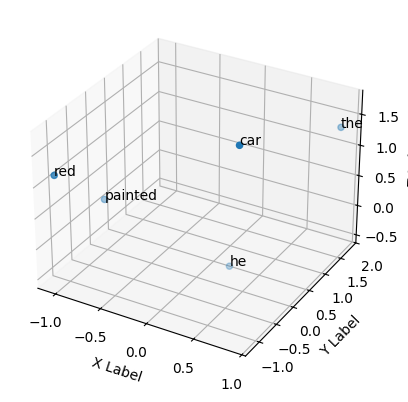

In [234]:
plot_embeddings(positional_embedding_sin.detach().numpy(),tokenizor(sample_text), vocab)

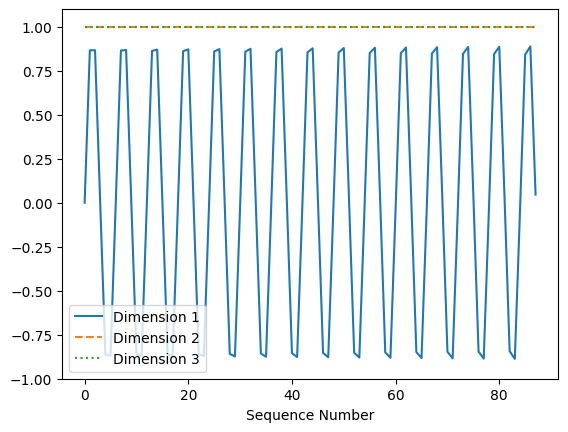

In [235]:
# Plot the positional encodings with different line styles and markers
plt.plot(pe[:, 0].numpy(), label="Dimension 1", linestyle='-')
plt.plot(pe[:, 1].numpy(), label="Dimension 2", linestyle='--')
plt.plot(pe[:, 2].numpy(), label="Dimension 3", linestyle=':')

# Adjust the y-axis scale for better visibility
plt.ylim([-1, 1.1])

plt.xlabel("Sequence Number")
plt.legend()
plt.show()

In our exploration of word embeddings, we've noticed a fascinating pattern: words are generally positioned close enough in the embedding space to preserve their proximity, ensuring that they are contextually related while maintaining distinctiveness from one another. However, there's a significant exception that arises specifically with the word 'car.'

This peculiar behavior can be attributed to the nature of the sine wave used in positional encoding. The sine wave is inherently periodic, meaning it repeats its pattern at regular intervals. This periodicity is visually illustrated in the accompanying image, where you can observe the sinusoidal curve repeating itself. As a result, the positional encoding for the word 'car' at different locations within the sequence remains the same.

This periodic nature poses a challenge, especially for words like 'car,' which may appear multiple times in a sequence but carry different contextual meanings each time. Despite their varying contexts, the positional encoding for all occurrences of 'car' would be identical due to the repetitive pattern of the sine wave.


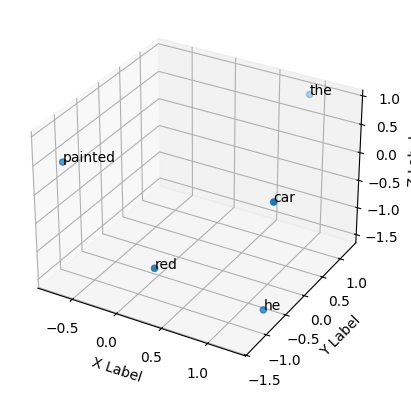

In [236]:
# so we adhere sin and cosine curve instead of using one

pe = torch.cat((torch.cos(2 * 3.14* positions/25), torch.sin(2 * 3.14* positions/25),
                torch.sin(2*3.14*positions/5)),axis = 1)

pos_embeddings_combine = embed_out + pe[0:samples,0:dims]
plot_embeddings(pos_embeddings_combine.detach().numpy(), tokenizor(sample_text),vocab)

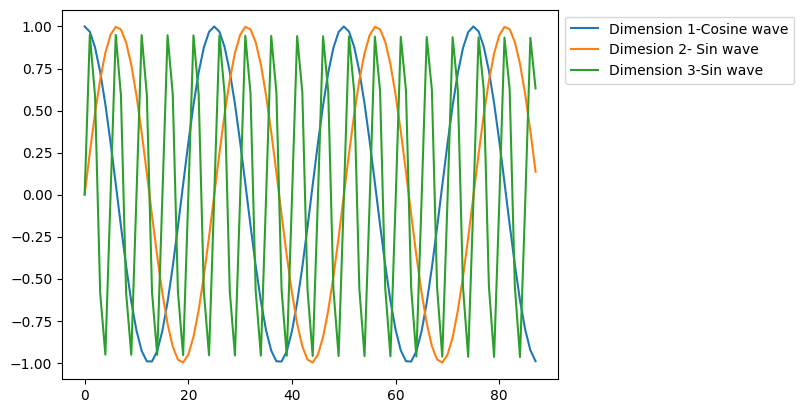

In [237]:
plt.plot(pe[:,0], label ="Dimension 1-Cosine wave")
plt.plot(pe[:,1], label = "Dimesion 2- Sin wave")
plt.plot(pe[:,2], label = "Dimension 3-Sin wave")

plt.legend(loc = "upper left", bbox_to_anchor = (1,1))
plt.show()

Overall, periodic functions provide a more expressive and adaptable means of encoding positional information in sequences, making them a preferred choice in modern sequence-to-sequence models like transformers. They offer improved capabilities for modeling both short-range and long-range dependencies, which are crucial for tasks in natural language processing and other domains.


Now that you understand positional encoding, embeddings, and self-attention, let’s combine these components to build a Transformer model that processes input sequences for downstream tasks.

### **Positional Embedding Class**

In [238]:
class PositionalEmbedding(nn.Module):
    
    def __init__(self, vocab_size, embed_dim,dropout = 0.3):
        super(PositionalEmbedding,self).__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        
        self.positional_encoding = torch.zeros(vocab_size, embed_dim)
        self.positions = torch.arange(0, vocab_size,dtype=torch.float).unsqueeze(1)
        
        pe = torch.cat((torch.cos(2 * 3.14* self.positions/25), torch.sin(2 * 3.14 * self.positions/25),
                             torch.sin(2 * 3.14 * self.positions/5)))
        
        self.register_buffer("pe",pe)
        
    def forward(seld, x):
        # Add positional encoding to each embedding vector assuming x is (seq_len, batch_size, n_embd)
        position_embedding = x + pe[0:x.size(0),:]
        return position_embedding
        

In [239]:
class Head(nn.Module):
    
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        
        self.embeddings = nn.Embedding(vocab_size,embed_dim)
        self.pos_embedding = PositionalEmbedding(vocab_size,embed_dim)
        
        self.query = nn.Linear(embed_dim,embed_dim,bias=False)
        self.key = nn.Linear(embed_dim,embed_dim,bias=False)
        self.value = nn.Linear(embed_dim,embed_dim,bias=False)
        
    def forward(self, x):
        # x -> (seq_len, batch_size, n_embeds)
        embed_out = self.embeddings(x)
        # positional embedding
        pos_embedding = self.pos_embedding(embed_out)
        
        # query, key, value
        q = self.query(pos_embedding)
        k = self.key(pos_embedding)
        v = self.value(pos_embedding)
        
        # attention weight
        w_out = q @ k.transpose(-2,-1) * k.shape[-1] ** -0.5 
        
        w_out = torch.nn.functional.softmax(w_out,dim=-1)
        
        out = w_out @ v
        
        return out
        

### Test the Transformer

In [240]:
input_data = torch.tensor(text_pipeline(sample_text),dtype=torch.long)
print(input_data)

tensor([ 0, 58,  2,  3, 14])


In [241]:
transformer = Head(vocab_size,embed_dim)

out = transformer(input_data)
print(f"output: {out}, output shape: {out.shape}")

output: tensor([[-0.4928, -0.7102,  0.2636],
        [-0.4251, -0.7263,  0.1815],
        [-0.1603, -0.7336,  0.1162],
        [-1.0840, -0.6718,  0.5474],
        [-1.0321, -0.7104,  0.4695]], grad_fn=<MmBackward0>), output shape: torch.Size([5, 3])


### **for class PositionalEmbedding it will more accurate when we use maximum sequence for assign positions and sin and cosine for even, odd dimesnions**

In [242]:
import math
import torch.nn as nn

In [243]:
max_seq_len = 500
dropout_value = 0.1
embed_dim = 4

In [259]:
class PositionalEmbedding(nn.Module):
    
    def __init__(self, embed_dim, max_seq_len, drop):
        super(PositionalEmbedding,self).__init__()
        
        self.dropout = nn.Dropout(drop)
        self.max_seq_len = max_seq_len
        
        positions = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        position_encodings = torch.zeros(max_seq_len,embed_dim)
        
        div_term = torch.exp(torch.arange(0,embed_dim,2).float() * 
                             (-math.log(10000.0)) /embed_dim 
                             )
        
        position_encodings[:,0::2] = torch.sin(positions * div_term)
        position_encodings[:,1::2] = torch.cos(positions * div_term)
        print(position_encodings)
        position_encodings = position_encodings.unsqueeze(0)
        self.register_buffer("position_encodings",position_encodings)
        
    def forward(self,word_embedding):
        
        seq_len = word_embedding.size(1)
        print(word_embedding.size())
        print(seq_len) 
        print(word_embedding)
        pos_embedding = word_embedding + self.position_encodings[:,:seq_len+1,:]
        return self.dropout(pos_embedding)
        

In [260]:
class Head(nn.Module):
    
    def __init__(self, vocab_len, embed_dim, max_seq_len, dropout):
        
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_len,embed_dim)
        self.pos_embedding = PositionalEmbedding(embed_dim,max_seq_len, dropout)
        
        self.query = nn.Linear(embed_dim,embed_dim,bias=False)
        self.key = nn.Linear(embed_dim,embed_dim,bias=False)
        self.value = nn.Linear(embed_dim,embed_dim,bias=False)
    
    def attention(self,x_seq):
        
        #x_seq : (seq_len ,batch_size, n_embeds)
        
        embed_out = self.embedding(x_seq)
        pos_embedding = self.pos_embedding(embed_out)
        
        q = self.query(pos_embedding)
        k = self.key(pos_embedding)
        v = self.value(pos_embedding)
        
        # attention weights
        weights = q @ k.transpose(-2,-1) * k.shape[-1] ** -0.5
        weights = torch.nn.functional.softmax(weights, dim = -1)

        
        return embed_out, weights,q,k,v
    
        
    def forward(self,x_seq):
        
        #x_seq : (seq_len ,batch_size, n_embeds)
        
        embed_out = self.embedding(x_seq)
        pos_embedding = self.pos_embedding(embed_out)
        
        q = self.query(pos_embedding)
        k = self.key(pos_embedding)
        v = self.value(pos_embedding)
        
        # attention weights
        weights = q @ k.transpose(-2,-1) * k.shape[-1] ** -0.5
        weights = torch.nn.functional.softmax(weights, dim = -1)
        
        out = weights @ v
        
        return out
        

In [262]:
transformer_new = Head(vocab_size,embed_dim, max_seq_len,dropout_value)

transformer_out = transformer_new(input_data)
print(f"output: {transformer_out}")


tensor([[ 0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.0100,  0.9999],
        [ 0.9093, -0.4161,  0.0200,  0.9998],
        ...,
        [ 0.5878,  0.8090, -0.9670,  0.2548],
        [ 0.9983, -0.0575, -0.9644,  0.2644],
        [ 0.4910, -0.8712, -0.9617,  0.2741]])
torch.Size([5, 4])
4
tensor([[-1.7761, -0.9920,  0.3696, -1.2473],
        [-0.1889, -1.2006, -0.5162,  0.2455],
        [ 0.3915, -0.1218,  1.1642,  0.2093],
        [ 1.5032, -0.8428, -0.7600, -0.4342],
        [ 0.0820, -0.7719, -1.5031, -1.9489]], grad_fn=<EmbeddingBackward0>)
output: tensor([[[ 0.2079, -0.0690, -0.1430,  0.0594],
         [ 0.7712,  0.4652, -0.1809, -0.3133],
         [ 0.7747,  0.4707, -0.1853, -0.3191],
         [ 0.7874,  0.4577, -0.1884, -0.3010],
         [ 0.4477,  0.1334, -0.1575, -0.0701]]], grad_fn=<UnsafeViewBackward0>)


## Transformers in PyTorch

In this section, you will learn how to build Transformer models using PyTorch’s `nn` module.

The provided code initializes a Transformer model from the neural network library. The `nhead` parameter defines the number of attention heads used in the multi-head attention mechanism, which is a key part of the Transformer architecture. In this example, it is set to 16.

The `num_encoder_layers` parameter specifies how many encoder layers are stacked within the Transformer. In this case, the model uses 12 encoder layers.


In [264]:
transformer_model = torch.nn.Transformer(nhead=16,num_encoder_layers=12)

These two lines create random tensors to represent the source and target sequences for the Transformer model.

`src` represents 10 source sequences, each with a length of 32 and a feature dimension of 512.
`tgt` represents 20 target sequences, each with a length of 32 and a feature dimension of 512.
In the context of sequence-to-sequence tasks, the source sequences are the input data (e.g., sentences in one language), and the target sequences are the desired output (e.g., the corresponding sentences in another language).


In [ ]:
src = torch.rand((10,32,512))
tgt = torch.rand((20,32,512))

In [266]:
output = transformer_model(src,tgt)
output

tensor([[[ 0.5841, -1.3237, -0.3664,  ...,  0.2920,  0.9798,  0.2692],
         [ 0.7855, -0.3690, -0.3999,  ..., -0.4479,  1.7228,  0.7117],
         [ 0.3375, -0.0715,  0.1255,  ..., -1.1637,  1.4081,  0.2623],
         ...,
         [ 1.1926, -0.1484,  0.5865,  ..., -0.6595,  0.6750,  0.5142],
         [ 0.6219, -0.0489, -0.4116,  ..., -1.0201,  0.5919,  0.4635],
         [ 1.2387,  0.0539, -0.0257,  ..., -0.2416,  0.0056,  0.1337]],

        [[ 0.3183, -0.1448, -0.2635,  ..., -0.4445,  1.1427, -0.0952],
         [ 0.5073, -0.4191, -0.4648,  ...,  0.2454,  1.3725,  0.4052],
         [ 0.4272,  0.0327,  0.4023,  ..., -0.7206,  1.6311,  0.6859],
         ...,
         [ 0.1252, -1.1177,  0.3929,  ..., -0.8671,  0.2429,  0.3180],
         [ 0.6377, -0.8390, -0.2709,  ..., -1.0690,  1.2047,  1.0721],
         [ 1.0028, -0.3642, -1.2341,  ..., -0.1866, -0.3209,  0.3830]],

        [[ 0.7817, -0.4964, -0.2572,  ...,  0.8163,  0.8259,  0.1669],
         [ 0.6943, -0.5642,  0.2555,  ..., -0

## MultiHead attention

`nn.MultiheadAttention` is a module in PyTorch that implements the multi-head self-attention mechanism, a key component of the Transformer architecture. This attention mechanism enables the model to focus on different parts of the input sequence simultaneously, capturing various contextual dependencies and improving the model's ability to process complex natural language patterns.



The multi-head attention mechanism works by first splitting the `query`, `key`, and `value` inputs into multiple "heads," each with its own set of learnable weights. This process allows the model to learn different attention patterns in parallel. 

The outputs from all heads are concatenated and passed through a linear layer, known as the output projection, to combine the information learned by each head. This final output represents the contextually enriched sequence that can be used in subsequent layers of the Transformer model.


In [267]:
embed_dim = 4
num_heads = 2
print(f"should be zero: {embed_dim %num_heads}")

should be zero: 0


In [269]:
seq_len = 10
batch_size = 5

query = torch.rand((seq_len,batch_size,embed_dim))
key = torch.rand((seq_len,batch_size, embed_dim))
value = torch.rand((seq_len,batch_size,embed_dim))

In [268]:
multihead_atten = nn.MultiheadAttention(embed_dim,num_heads,batch_first=False)

In [270]:
atten_out, _ = multihead_atten(query, key,value)
print(f"attention output: {atten_out}, shape: {atten_out.shape}")

attention output: tensor([[[-0.2025,  0.0439,  0.0486,  0.0706],
         [-0.1818,  0.0538, -0.0112,  0.1356],
         [-0.2872,  0.0779,  0.0594,  0.0610],
         [-0.1513,  0.0663,  0.0398,  0.0728],
         [-0.2337,  0.0943,  0.0258,  0.0882]],

        [[-0.2036,  0.0465,  0.0499,  0.0685],
         [-0.1829,  0.0541, -0.0122,  0.1361],
         [-0.2897,  0.0790,  0.0580,  0.0621],
         [-0.1474,  0.0642,  0.0429,  0.0722],
         [-0.2343,  0.0949,  0.0251,  0.0884]],

        [[-0.2049,  0.0495,  0.0506,  0.0663],
         [-0.1824,  0.0540, -0.0111,  0.1356],
         [-0.2901,  0.0792,  0.0567,  0.0621],
         [-0.1469,  0.0641,  0.0434,  0.0724],
         [-0.2338,  0.0946,  0.0253,  0.0883]],

        [[-0.2026,  0.0445,  0.0493,  0.0699],
         [-0.1826,  0.0540, -0.0118,  0.1360],
         [-0.2923,  0.0801,  0.0540,  0.0629],
         [-0.1497,  0.0654,  0.0411,  0.0725],
         [-0.2351,  0.0955,  0.0241,  0.0885]],

        [[-0.2040,  0.0474,  0.051